# Assignment 3: Using Compilation Techniques and GPUs for Optimization
Group 15

- NG, Cheuk Nam (cnng@kth.se)
- WONG, Chun Him (chwon@kth.se)

## Dependencies

In [1]:
!pip install line_profiler
!pip install memory_profiler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.2 MB/s eta 0:00:00


## Extensions

In [2]:
%load_ext line_profiler
%load_ext memory_profiler

## Imports

In [3]:
import time
import random
import statistics
import matplotlib.pyplot as plt

# Exercise 1: Gauss-Seidel for Poisson Solver

## Task 1.1: Develop the Gauss-Seidel solver with Python List, array, or NumPy

### Implmentation with Python List

In [11]:
def gauss_seidel_list(f, N):
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] + f[i+1][j] + f[i-1][j])
    return f

### Profiling

#### Grid Initialiser

In [8]:
def initialise_grid(N):
    grid = [[random.random() for _ in range(N)] for _ in range(N)]
    for i in range(N):
        grid[i][0] = grid[i][N-1] = 0
        grid[0][i] = grid[N-1][i] = 0
    return grid

In [9]:
def initialise_and_run(N, iterations):
    f = initialise_grid(N)
    for _ in range(iterations):
        f = gauss_seidel_list(f, N)
    return f

In [10]:
def run_only(f, N, iterations):
    for _ in range(iterations):
        f = gauss_seidel_list(f, N)
    return f

#### Profiling for Execution Time

In [7]:
def profile_time(run_only_func, init_func, grid_sizes,
                          iterations=1000, runs_per_size=10, title="Python Lists"):
    means = []
    stds = []

    print(f"Starting profiling: {iterations} iterations per run, {runs_per_size} runs per size.")

    for N in grid_sizes:
        run_times = []
        print(f"Grid {N}x{N}: Running {runs_per_size} samples", end=" ", flush=True)

        for _ in range(runs_per_size):
            f = init_func(N)

            start_time = time.perf_counter()
            f = run_only_func(f, N, iterations)
            end_time = time.perf_counter()

            run_times.append(end_time - start_time)

        avg = statistics.mean(run_times)
        sd = statistics.stdev(run_times) if len(run_times) > 1 else 0
        means.append(avg)
        stds.append(sd)
        print(f"Avg: {avg:.4f}s")

    plt.figure(figsize=(10, 6))
    plt.errorbar(grid_sizes, means, yerr=stds, fmt='-o', capsize=5,
                 linewidth=2, markersize=8, color='#2c3e50', ecolor='#e74c3c',
                 label=f'{title} ({iterations} iterations)')

    plt.title(f'Performance Profile: {title}', fontsize=14)
    plt.xlabel('Grid Size ($N \times N$)', fontsize=12)
    plt.ylabel('Execution Time (seconds)', fontsize=12)

    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return means, stds

Starting profiling: 1000 iterations per run, 10 runs per size.
Grid 50x50: Running 10 samples Avg: 0.2984s
Grid 100x100: Running 10 samples Avg: 1.2539s
Grid 150x150: Running 10 samples Avg: 2.9888s
Grid 200x200: Running 10 samples Avg: 5.4056s
Grid 250x250: Running 10 samples Avg: 8.3352s
Grid 300x300: Running 10 samples Avg: 12.3829s
Grid 350x350: Running 10 samples Avg: 17.1509s
Grid 400x400: Running 10 samples Avg: 22.9602s
Grid 450x450: Running 10 samples Avg: 29.5659s
Grid 500x500: Running 10 samples Avg: 36.7659s


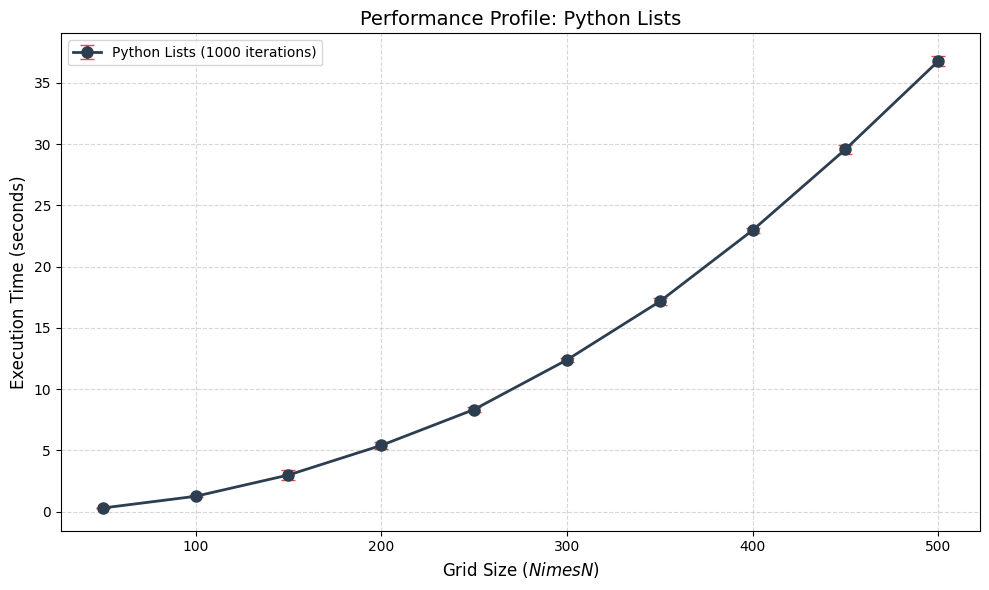

([0.29836690240001074,
  1.2539261683000062,
  2.9888415429000075,
  5.405598902799994,
  8.335224772399988,
  12.382901290600023,
  17.150925721900002,
  22.960164073000033,
  29.5659059782,
  36.765869649399995],
 [0.0084600593461029,
  0.0898520725938767,
  0.42335217121172436,
  0.28215683330422586,
  0.17256791702729807,
  0.16558390154788769,
  0.2674801399185499,
  0.1961960881199884,
  0.34134599390035975,
  0.4233363364931222])

In [9]:
grid_sizes = range(50, 550, 50)
iterations = 1000
runs_per_size = 10

profile_time(run_only, initialise_grid, grid_sizes, iterations, runs_per_size)

From the above results we can see that the execution time increases quadratically as we have a nested for loop inside.

## Task 1.2: Profile the code to identify the part of the code to optimise

### Methods and Tools

- %prun: a magic command that provides the same functionality as the cProfile module.
- %lprun: a magic command that provides line-by-line profiling of functions.
- %mprun: a magic command that provides memory profiling of functions.

### Conditions

- Grid size: 100
- Gauss-Seidel Iterations: 1000
- Runs per size: 1

> cProfile is skipped as we only have a single function for this scenario.

### Line-by-line Profiling `gauss_seidel_list`

In [10]:
%lprun -f gauss_seidel_list initialise_and_run(100, 1000)


*** KeyboardInterrupt exception caught in code being profiled.


```
Timer unit: 1e-09 s

Total time: 8.93418 s

gauss_seidel_list

Line #      Hits         Time  Per Hit   % Time
==============================================================
     1                                           
     2     99000   37448558.0    378.3      0.4  
     3   9702000 3578991651.0    368.9     40.1  
     4   9604000 5313929994.0    553.3     59.5  
     5      1000    3808819.0   3808.8      0.0
```

From the line_profile results, we can see that the arithmetic operation on line 4 of the function `f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] + f[i+1][j] + f[i-1][j])` unsuprisingly takes most of the execution time. Optimisation could be prioritised to speed up the operation on list cells.

## Task 1.3: Use the Cython Annotation tool to identify the parts to use Cython

### Creating the .pyx File

In [11]:
%%writefile gauss_seidel_cy.pyx

def gauss_seidel_list(f, N):
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] + f[i+1][j] + f[i-1][j])
    return f

Writing gauss_seidel_cy.pyx


### Analysing the .pyx File with Cython

In [ ]:
!cython -a gauss_seidel_cy.pyx

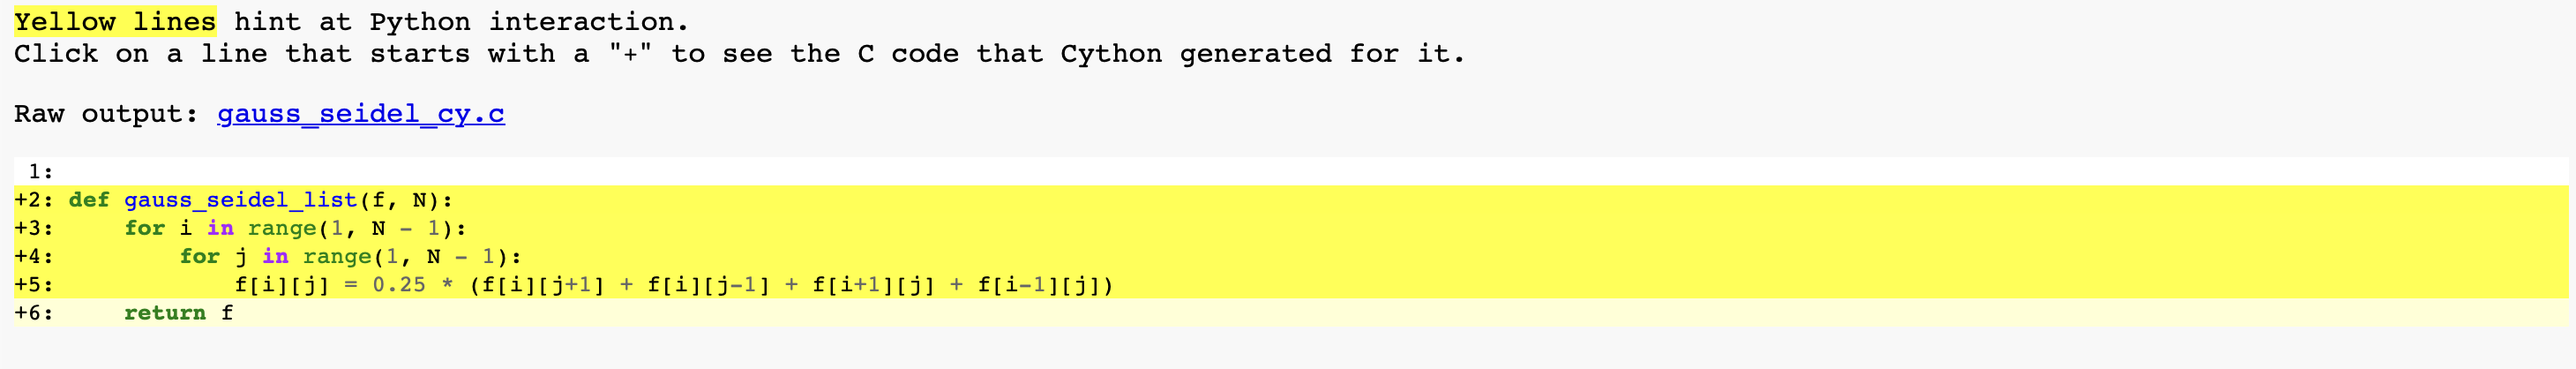

We can see that except line 6, all other lines has a high intensity of yellow background, that means they all make a lot of callbacks to the Python Virtual Machine, we should declare the types of most of the objects in this function.

## Task 1.4: Use Cython to optimise the part you identified as the most computationally expensive

### Creating the .pyx file with types

In [12]:
%%writefile gauss_seidel_cy_typed.pyx

#cython: boundscheck=False
def gauss_seidel_list(f: list, unsigned int N):
    cdef unsigned int i, j
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            f[i][j] = 0.25 * (f[i][j+1] + f[i][j-1] + f[i+1][j] + f[i-1][j])
    return f

Writing gauss_seidel_cy_typed.pyx


### Creating setup_typed.py

In [13]:
%%writefile setup_typed.py
from distutils.core import setup
from Cython.Build import cythonize

setup(ext_modules = cythonize("gauss_seidel_cy_typed.pyx", compiler_directives={"language_level": "3"}))

Writing setup_typed.py


### Analysing the typed .pyx File with Cython

In [ ]:
!cython -a gauss_seidel_cy_typed.pyx

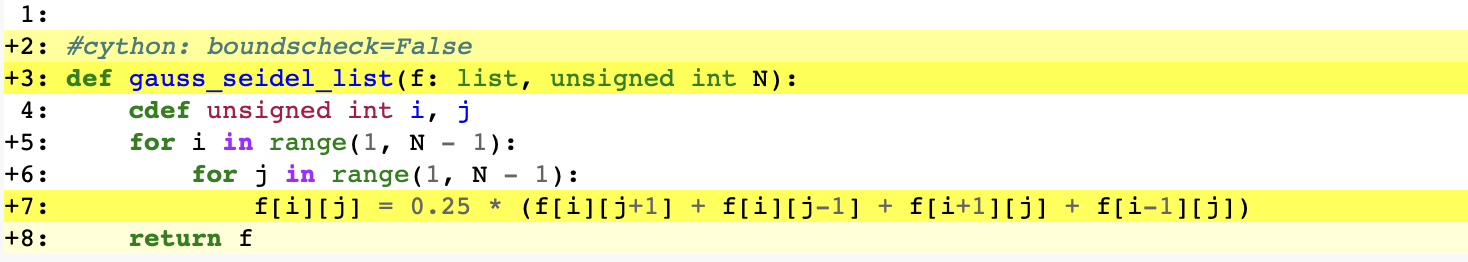

We can see that now for the for-loop lines are turned white after the type annotations.

### Calling the Typed Cythonised Code

In [14]:
!python setup_typed.py build_ext --inplace

Compiling gauss_seidel_cy_typed.pyx because it changed.
[1/1] Cythonizing gauss_seidel_cy_typed.pyx


In [15]:
import gauss_seidel_cy_typed
def run_only_cythonised_typed(f, N, iterations):
    for _ in range(iterations):
        f = gauss_seidel_cy_typed.gauss_seidel_list(f, N)
    return f

### Profiling the Execution Time

Starting profiling: 1000 iterations per run, 10 runs per size.
Grid 50x50: Running 10 samples Avg: 0.1360s
Grid 100x100: Running 10 samples Avg: 0.5918s
Grid 150x150: Running 10 samples Avg: 1.3763s
Grid 200x200: Running 10 samples Avg: 2.4967s
Grid 250x250: Running 10 samples Avg: 4.0381s
Grid 300x300: Running 10 samples Avg: 6.0146s
Grid 350x350: Running 10 samples Avg: 9.0146s
Grid 400x400: Running 10 samples Avg: 11.5913s
Grid 450x450: Running 10 samples Avg: 14.4773s
Grid 500x500: Running 10 samples Avg: 17.7811s


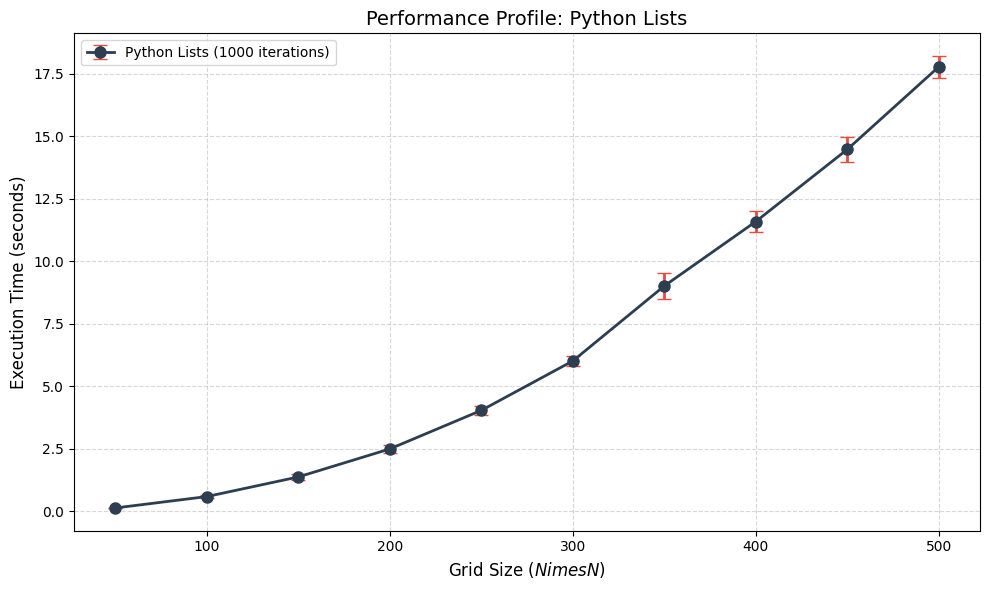

([0.13602656870002647,
  0.5917695010999978,
  1.3762733727000522,
  2.4967149994001376,
  4.038131832000045,
  6.014646071600055,
  9.014571647899903,
  11.591317232500023,
  14.477301819800005,
  17.78108531930002],
 [0.005460360057713249,
  0.04696154124850284,
  0.12336264058754114,
  0.15011812270205724,
  0.18860553897294688,
  0.20308073123797288,
  0.5240900937431717,
  0.42945434099342594,
  0.503263775236794,
  0.43281262783395746])

In [16]:
grid_sizes = range(50, 550, 50)
iterations = 1000
runs_per_size = 10

profile_time(run_only_cythonised_typed, initialise_grid, grid_sizes, iterations, runs_per_size)

When comparing this to the profiling of the non-Cython code, it's evident that the graph's gradient is significantly less. Although the code still runs in quadratic time, the improvements are measurable in seconds.

## Task 1.5 Use PyTorch to port your code to Nvidia GPUs

In [4]:
import torch
from torch import (roll, rand)

def initialise_grid_torch(N):
    grid_shape = (N, N)

    grid = rand(grid_shape)

    grid[0, :] = 0.0
    grid[-1, :] = 0.0
    grid[:, 0] = 0.0
    grid[:, -1] = 0.0

    if torch.cuda.is_available():
        grid = grid.cuda()

    return grid

def jacobi_torch(f):
    g = 0.25 * (
          roll(f, +1, 0)
        + roll(f, -1, 0)
        + roll(f, +1, 1)
        + roll(f, -1, 1)
    )

    g[0, :] = 0.0
    g[-1, :] = 0.0
    g[:, 0] = 0.0
    g[:, -1] = 0.0

    return g

def run_only_torch(f, N, iterations):
    for _ in range(iterations):
      f = jacobi_torch(f)
    return f

## Task 1.6: Use CuPy to port your code to Nvidia GPUs

In [5]:
import numpy as np
import cupy as cp

def initialise_grid_cupy(N):
    grid = cp.random.random((N, N)).astype(cp.float32)

    grid[0, :] = 0
    grid[-1, :] = 0
    grid[:, 0] = 0
    grid[:, -1] = 0

    return grid

def jacobi_cupy(f, N):
    g = 0.25 * (
        cp.roll(f,  1, axis=0) +
        cp.roll(f, -1, axis=0) +
        cp.roll(f,  1, axis=1) +
        cp.roll(f, -1, axis=1)
    )

    g[0, :] = 0
    g[-1, :] = 0
    g[:, 0] = 0
    g[:, -1] = 0

    return g

def run_only_cupy(f, N, iterations=1000):
    for _ in range(iterations):
        f = jacobi_cupy(f, N)

    return f

## Task 1.7: Measure the performance (execution time) with GPU (PyTorch and CuPy)

### Pytorch

Starting profiling: 1000 iterations per run, 10 runs per size.
Grid 50x50: Running 10 samples Avg: 0.2860s
Grid 150x150: Running 10 samples Avg: 0.1216s
Grid 250x250: Running 10 samples Avg: 0.1469s
Grid 350x350: Running 10 samples Avg: 0.1729s
Grid 450x450: Running 10 samples Avg: 0.1236s
Grid 550x550: Running 10 samples Avg: 0.1228s
Grid 650x650: Running 10 samples Avg: 0.1218s
Grid 750x750: Running 10 samples Avg: 0.1534s
Grid 850x850: Running 10 samples Avg: 0.2106s
Grid 950x950: Running 10 samples Avg: 0.2856s
Grid 1050x1050: Running 10 samples Avg: 0.3520s
Grid 1150x1150: Running 10 samples Avg: 0.4196s
Grid 1250x1250: Running 10 samples Avg: 0.4958s
Grid 1350x1350: Running 10 samples Avg: 0.5802s
Grid 1450x1450: Running 10 samples Avg: 0.6728s
Grid 1550x1550: Running 10 samples Avg: 0.7764s
Grid 1650x1650: Running 10 samples Avg: 0.8914s
Grid 1750x1750: Running 10 samples Avg: 0.9965s
Grid 1850x1850: Running 10 samples Avg: 1.0856s
Grid 1950x1950: Running 10 samples Avg: 1.1894s

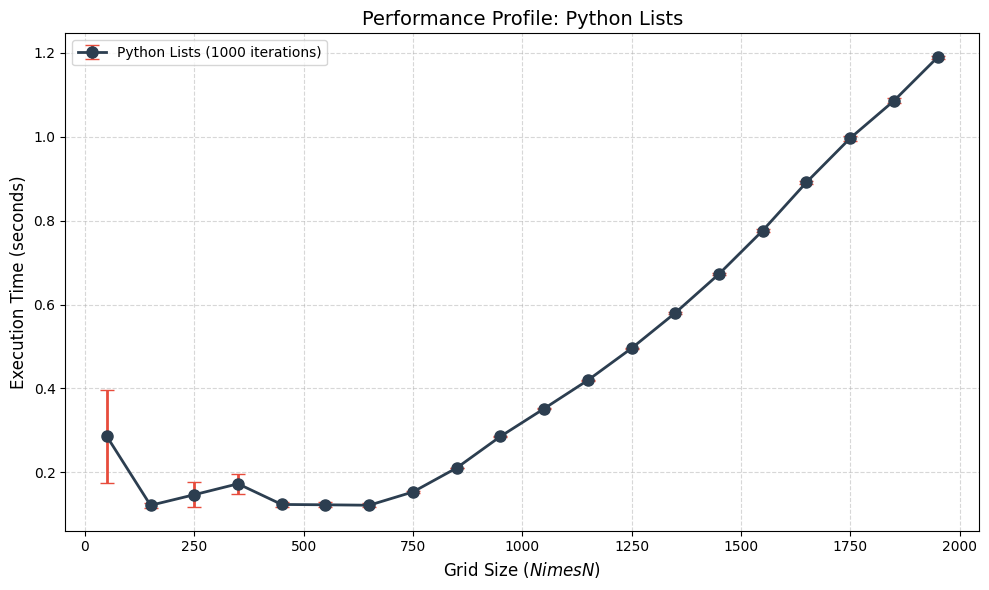

([0.28596660330000534,
  0.12158235919999641,
  0.14686613020000722,
  0.17286139929999536,
  0.12360982159999878,
  0.12283779309999829,
  0.1217856705999992,
  0.15341799929999525,
  0.21062141669999618,
  0.28559558130000084,
  0.3520335222,
  0.4196391752000011,
  0.4958150948000025,
  0.5801564210000038,
  0.672818535899998,
  0.7763671194000068,
  0.8913589704000031,
  0.9964789463999921,
  1.0855915900000013,
  1.189404168699997],
 [0.1102529944844641,
  0.006665090637230565,
  0.029378502718569552,
  0.023134487905238976,
  0.006454395172765397,
  0.0061812825047781895,
  0.005341400659960788,
  0.001619311327382977,
  0.0004191193266659742,
  0.000563720042607715,
  0.0006988344791944943,
  0.0006818930157096357,
  0.0012210581241377215,
  0.002756284281798114,
  0.0024233874347593456,
  0.003755798472675393,
  0.004280356644996669,
  0.006019563265196284,
  0.006230873523458286,
  0.0030654401710099744])

In [12]:
grid_sizes = range(50, 2050, 100)
iterations = 1000
runs_per_size = 10

profile_time(run_only_torch, initialise_grid_torch, grid_sizes, iterations, runs_per_size)

### CuPy

Starting profiling: 1000 iterations per run, 10 runs per size.
Grid 50x50: Running 10 samples Avg: 0.5088s
Grid 150x150: Running 10 samples Avg: 0.5228s
Grid 250x250: Running 10 samples Avg: 0.4914s
Grid 350x350: Running 10 samples Avg: 0.4684s
Grid 450x450: Running 10 samples Avg: 0.5510s
Grid 550x550: Running 10 samples Avg: 0.6281s
Grid 650x650: Running 10 samples Avg: 0.6900s
Grid 750x750: Running 10 samples Avg: 0.4796s
Grid 850x850: Running 10 samples Avg: 0.5570s
Grid 950x950: Running 10 samples Avg: 0.4823s
Grid 1050x1050: Running 10 samples Avg: 0.4948s
Grid 1150x1150: Running 10 samples Avg: 0.5540s
Grid 1250x1250: Running 10 samples Avg: 0.5254s
Grid 1350x1350: Running 10 samples Avg: 0.6425s
Grid 1450x1450: Running 10 samples Avg: 0.6927s
Grid 1550x1550: Running 10 samples Avg: 0.7840s
Grid 1650x1650: Running 10 samples Avg: 0.8812s
Grid 1750x1750: Running 10 samples Avg: 0.9861s
Grid 1850x1850: Running 10 samples Avg: 1.0965s
Grid 1950x1950: Running 10 samples Avg: 1.2137s

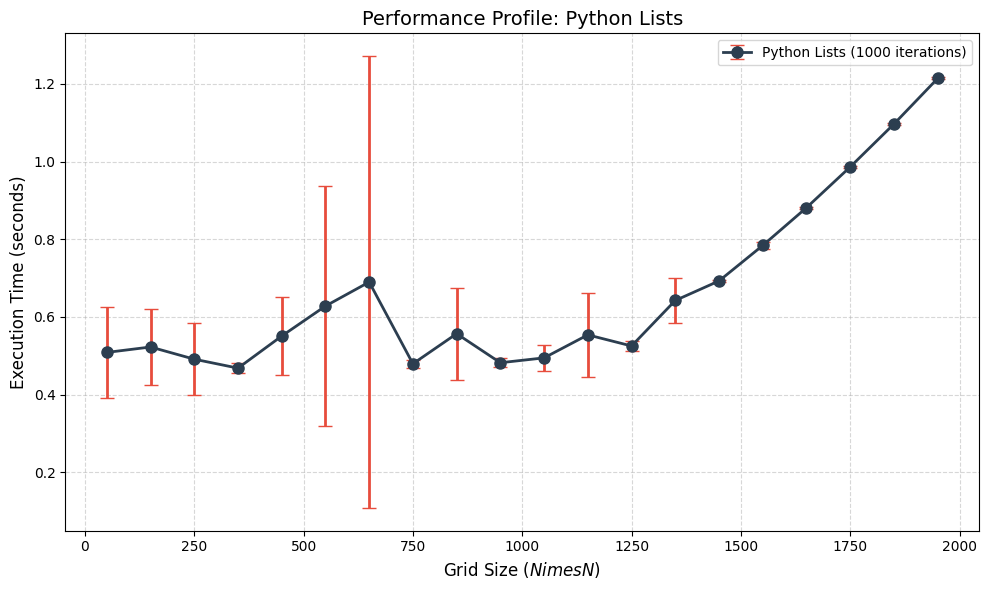

([0.5088341447000004,
  0.5228039424000087,
  0.49141797849999874,
  0.4684177168000076,
  0.5509863951999989,
  0.6281443506000016,
  0.6899628037000014,
  0.4796136043999809,
  0.5570376264000003,
  0.4823124516000007,
  0.4948416595999959,
  0.5540093696999918,
  0.5254218275999847,
  0.6425009323000097,
  0.6927424442000018,
  0.7840294248000077,
  0.8812281239000072,
  0.9860978596000052,
  1.0964780945999961,
  1.2137267068999846],
 [0.116227797139615,
  0.09652545321851273,
  0.0931439206560317,
  0.01251577411431607,
  0.1000522824754182,
  0.30976229066244826,
  0.5816955982574812,
  0.009578847278993465,
  0.11870741256950772,
  0.011626962917149337,
  0.033926000495281626,
  0.10826969849132884,
  0.012993385980112833,
  0.05731669406026293,
  0.0020849783120708027,
  0.008341853900709717,
  0.0021869396856509316,
  0.0022570320415593293,
  0.002830322483433186,
  0.002605419578661229])

In [13]:
grid_sizes = range(50, 2050, 100)
iterations = 1000
runs_per_size = 10

profile_time(run_only_cupy, initialise_grid_cupy, grid_sizes, iterations, runs_per_size)

### Analysis

For both of the implementations, we can obviously see that the execution time improvement is extremely significant when compared to the original implementation or Cython. However, we can notice a trend that for both Torch and CuPy, we can see that the execution times were fairly stable for some smaller $N$s, after some threshold ($N = 700$ for Torch and $N = 1200$ for CuPy), the exewcution times start to increase linearly. This should be coming from the number of concurrent jacobi calculations exeeding the number of CUDA cores, so a part of the calculations had to be queued.

### Task 1.8: Save the newgrid matrix as an hdf5 file using h5py

The following code saves a grid of size 100 after 1000 iterations as a hdf5 file.

In [14]:
import h5py

new_grid = initialise_grid_torch(100)

new_grid = run_only_torch(new_grid, 100, 1000)

dataset = new_grid.detach().cpu().numpy()

with h5py.File("newgrid.hdf5", 'w') as f:
  f.create_dataset("new_grid", data=dataset)

  print(f["new_grid"][25][9] == dataset[25][9]) #check if it is saved correcly

True


# Bonus Task
Mandelbrot Set

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def mandelbrot(c, max_iter=100):
    """Computes the number of iterations before divergence."""
    z = 0
    for n in range(max_iter):
        if abs(z) > 2:
            return n
        z = z*z + c
    return max_iter

def mandelbrot_set(width, height, x_min, x_max, y_min, y_max, max_iter=100):
    """Generates the Mandelbrot set image."""
    x_vals = np.linspace(x_min, x_max, width)
    y_vals = np.linspace(y_min, y_max, height)
    image = np.zeros((height, width))

    for i in range(height):
        for j in range(width):
            c = complex(x_vals[j], y_vals[i])
            image[i, j] = mandelbrot(c, max_iter)

    return image

# Parameters
width, height = 1000, 800
x_min, x_max, y_min, y_max = -2, 1, -1, 1

# Generate fractal
image = mandelbrot_set(width, height, x_min, x_max, y_min, y_max)

# Display
plt.imshow(image, cmap='inferno', extent=[x_min, x_max, y_min, y_max])
plt.colorbar()
plt.title("Mandelbrot Set")
plt.show()


## Task B.1
### Cython Optimization of the Mandelbrot Set

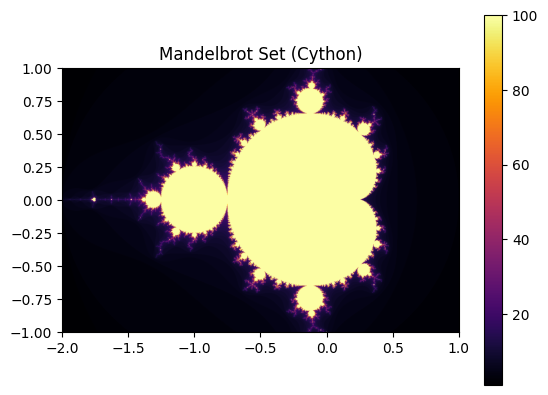

In [ ]:
# Task B.1: Run from asm3/ directory, or first: cd asm3 && python setup.py build_ext --inplace
import numpy as np
import matplotlib.pyplot as plt
from mandelbrot_cy import mandelbrot_set

# Parameters
width, height = 1000, 800
x_min, x_max, y_min, y_max = -2, 1, -1, 1

# Generate fractal (Cython-optimized)
image = mandelbrot_set(width, height, x_min, x_max, y_min, y_max)

# Display
plt.imshow(image, cmap='inferno', extent=[x_min, x_max, y_min, y_max])
plt.colorbar()
plt.title("Mandelbrot Set (Cython)")
plt.show()


## Task B.2

Computed on: cuda


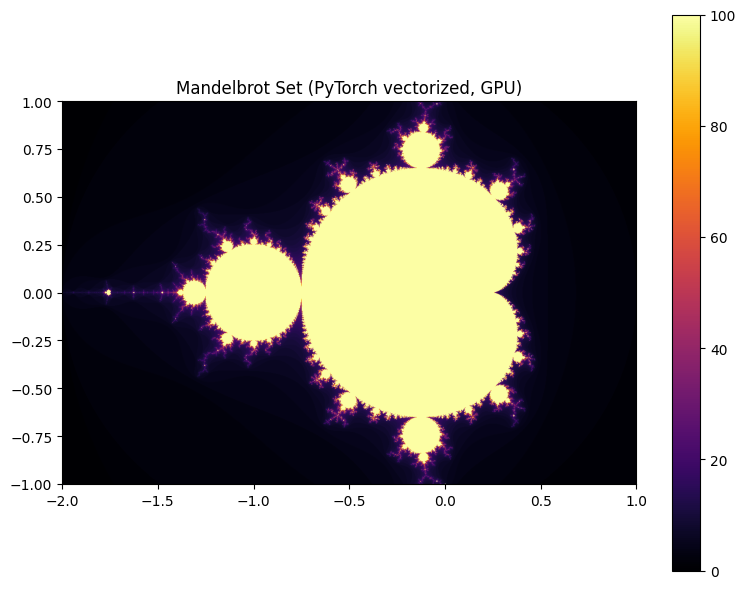

In [ ]:
import torch
import matplotlib.pyplot as plt


def mandelbrot_set_torch_gpu(width, height, x_min, x_max, y_min, y_max, max_iter=100, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

    x_vals = torch.linspace(x_min, x_max, width, dtype=torch.float64, device=device)
    y_vals = torch.linspace(y_min, y_max, height, dtype=torch.float64, device=device)
    x_2d, y_2d = torch.meshgrid(x_vals, y_vals, indexing='xy')
    C = torch.complex(x_2d, y_2d)

    Z = torch.zeros_like(C, device=device)
    output = torch.full((height, width), max_iter, dtype=torch.float64, device=device)
    mask = torch.ones((height, width), dtype=torch.bool, device=device)

    for n in range(max_iter):
        Z[mask] = Z[mask] * Z[mask] + C[mask]
        diverged = torch.abs(Z) > 2
        just_diverged = diverged & mask
        output[just_diverged] = n
        mask &= ~diverged

    return output.cpu().numpy()


# Same parameters
width, height = 1000, 800
x_min, x_max, y_min, y_max = -2, 1, -1, 1

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
image_gpu = mandelbrot_set_torch_gpu(width, height, x_min, x_max, y_min, y_max, max_iter=100, device=device)
print(f"Computed on: {device}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.imshow(image_gpu, cmap='inferno', extent=[x_min, x_max, y_min, y_max])
plt.colorbar(im, ax=ax)
ax.set_title("Mandelbrot Set (PyTorch vectorized, GPU)")
plt.tight_layout()
plt.show()

## Task B.3

In [ ]:
import sys
import os
_asm3 = os.path.join(os.getcwd(), 'asm3')
if os.path.isdir(_asm3):
    sys.path.insert(0, _asm3)
else:
    sys.path.insert(0, os.getcwd())

import numpy as np
import time
import torch
from mandelbrot_cy import mandelbrot_set as mandelbrot_set_cython


# --- Baseline ---
def mandelbrot_baseline(c, max_iter=100):
    z = 0
    for n in range(max_iter):
        if abs(z) > 2:
            return n
        z = z * z + c
    return max_iter

def mandelbrot_set_baseline(width, height, x_min, x_max, y_min, y_max, max_iter=100):
    x_vals = np.linspace(x_min, x_max, width)
    y_vals = np.linspace(y_min, y_max, height)
    image = np.zeros((height, width))
    for i in range(height):
        for j in range(width):
            c = complex(x_vals[j], y_vals[i])
            image[i, j] = mandelbrot_baseline(c, max_iter)
    return image


# --- Vectorized NumPy
def mandelbrot_set_vectorized(width, height, x_min, x_max, y_min, y_max, max_iter=100):
    x_vals = np.linspace(x_min, x_max, width, dtype=np.float64)
    y_vals = np.linspace(y_min, y_max, height, dtype=np.float64)
    x_2d, y_2d = np.meshgrid(x_vals, y_vals)
    C = x_2d + 1j * y_2d
    Z = np.zeros_like(C)
    output = np.full((height, width), max_iter, dtype=np.float64)
    mask = np.ones((height, width), dtype=bool)
    for n in range(max_iter):
        Z[mask] = Z[mask] * Z[mask] + C[mask]
        diverged = np.abs(Z) > 2
        output[diverged & mask] = n
        mask &= ~diverged
    return output


# --- PyTorch vectorized: CPU and GPU ---
def mandelbrot_set_torch(width, height, x_min, x_max, y_min, y_max, max_iter=100, device=None):
    if device is None:
        device = torch.device('cpu')
    x_vals = torch.linspace(x_min, x_max, width, dtype=torch.float64, device=device)
    y_vals = torch.linspace(y_min, y_max, height, dtype=torch.float64, device=device)
    x_2d, y_2d = torch.meshgrid(x_vals, y_vals, indexing='xy')
    C = torch.complex(x_2d, y_2d)
    Z = torch.zeros_like(C, device=device)
    output = torch.full((height, width), max_iter, dtype=torch.float64, device=device)
    mask = torch.ones((height, width), dtype=torch.bool, device=device)
    for n in range(max_iter):
        Z[mask] = Z[mask] * Z[mask] + C[mask]
        diverged = torch.abs(Z) > 2
        output[diverged & mask] = n
        mask &= ~diverged
    if device.type == 'cuda':
        torch.cuda.synchronize()
    return output.cpu().numpy()

width, height = 1000, 800
x_min, x_max, y_min, y_max = -2, 1, -1, 1
max_iter = 100
n_runs = 5  # number of runs per method for mean time

def time_fn(fn, *args, **kwargs):
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        fn(*args, **kwargs)
        times.append(time.perf_counter() - t0)
    return np.mean(times) * 1000  # ms

results = []

# Baseline
t_baseline = time_fn(mandelbrot_set_baseline, width, height, x_min, x_max, y_min, y_max, max_iter)
results.append(("Baseline (nested loop, Python)", t_baseline))

# Cython
t_cython = time_fn(mandelbrot_set_cython, width, height, x_min, x_max, y_min, y_max, max_iter)
results.append(("Cython (typed + memoryviews)", t_cython))

# NumPy vectorized
t_np_vec = time_fn(mandelbrot_set_vectorized, width, height, x_min, x_max, y_min, y_max, max_iter)
results.append(("NumPy vectorized (CPU)", t_np_vec))

# PyTorch vectorized CPU
t_torch_cpu = time_fn(mandelbrot_set_torch, width, height, x_min, x_max, y_min, y_max, max_iter, torch.device('cpu'))
results.append(("PyTorch vectorized (CPU)", t_torch_cpu))

# PyTorch vectorized GPU
gpu_device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else None)
if gpu_device is not None:
    try:
        torch.cuda.synchronize() if gpu_device.type == 'cuda' else None
        t_torch_gpu = time_fn(mandelbrot_set_torch, width, height, x_min, x_max, y_min, y_max, max_iter, gpu_device)
        if gpu_device.type == 'cuda':
            torch.cuda.synchronize()
        results.append((f"PyTorch vectorized ({gpu_device.type.upper()})", t_torch_gpu))
    except Exception as e:
        results.append(("PyTorch vectorized (GPU)", f"N/A ({type(e).__name__})"))
else:
    results.append(("PyTorch vectorized (GPU)", "N/A (no CUDA/MPS)"))

# Print table
print("Execution time (mean over {} runs, {}x{} pixels, max_iter={})\n".format(n_runs, width, height, max_iter))
print("{:40s} {:>12s}".format("Method", "Time (ms)"))
print("-" * 54)
for name, t in results:
    print("{:40s} {:>12}".format(name, f"{t:.2f}" if isinstance(t, (int, float)) else t))

Execution time (mean over 5 runs, 1000x800 pixels, max_iter=100)

Method                                      Time (ms)
------------------------------------------------------
Baseline (nested loop, Python)                1670.08
Cython (typed + memoryviews)                    40.06
NumPy vectorized (CPU)                         458.30
PyTorch vectorized (CPU)                       322.99
PyTorch vectorized (CUDA)                       74.02


### Comments on optimizations and performance

*(Based on Task B.3 output: mean over 5 runs, 1000×800 pixels, max_iter=100.)*

- Baseline (nested loop, Python): around 1670 ms — slowest by far. Every pixel runs a Python loop with Python `complex` and `abs()`, so each iteration pays interpreter and type overhead. Serves as the reference for comparing optimizations.

- Cython (typed + memoryviews): around 40 ms — fastest in this run (42× faster than baseline). Typing (`double`, `int`) and typed memoryviews compile the inner loop to C and remove Python overhead; `nogil` and no bounds checking reduce cost further. It avoids redundant work on already-diverged pixels and does not touch the full grid each iteration, so it outperforms both NumPy and PyTorch on CPU and, at this grid size, even the GPU version.

- NumPy vectorized (CPU): around 458 ms — much faster than baseline (3.6×) but slower than Cython (11×). It replaces pixel loops with array ops and Boolean masking (contiguous memory, vectorized ops), but every iteration updates and masks the full grid, including points that have already diverged, so it does more total work than Cython.

- PyTorch vectorized (CPU): around 323 ms — same vectorized algorithm as NumPy but on `torch` tensors. In this run it is a bit faster than NumPy (458 ms), likely due to efficient tensor ops; both are in the same order of magnitude.

- PyTorch vectorized (GPU): around 74 ms — second-fastest after Cython. The same vectorized logic runs on the GPU; parallelism and memory bandwidth give a large speedup over the CPU vectorized versions (4× vs PyTorch CPU, 6× vs NumPy). At 1000×800 the GPU is still slower than Cython (40 ms), which suggests that for this grid size and iteration count, kernel launch and memory transfer overhead matter; the GPU would be expected to win for larger grids or higher `max_iter`.

# AI Declaration

## Basic Part
- Task 1.1: AI is used for adding formatting for the plotted graph in function `profile_time`
  - Model: Gemini 3.1 Pro
  - Prompt: "Help me to beautify the output of the graph for profiling, including title and colours"
  - Validation: Checking if the generated plots can be clearly seen

- AI is not used in other parts.

## Bonus Part
- Task B.1: AI is used for brainstorming ideas to cythonise the code
  - Model: composer-1.5
  - Prompt: "Give me some idea to cythonise complex number"
  - Validation: Checking the mathematical meaning by myself and checked online

- Task B.2: AI suggested the way to use boolean masking
  - Model: composer-1.5
  - Prompt: "Suggest how to use Boolean masking to track which point is diverged"
  - Validation: Implemented logic checking by myself

- Task B.3: AI is used to plot the graph
  - Model: composer 1.5
  - Prompt: "With the given code, advise me on formatting and creating a graph"
  - Validation: Checked the graph and visualize data